In [1]:
pip install torch torchvision onnx onnxruntime pillow matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 48.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 57.9 MB/s eta 0:00:00


In [2]:
import torch
import torchvision.models as models

# Load pretrained model (ResNet18)
model = models.resnet18(pretrained=True)

# Set to evaluation mode
model.eval()

print("Model Loaded Successfully")

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 179MB/s]


Model Loaded Successfully


In [6]:
import torch.onnx
!pip install onnxscript

# Create dummy input (required for export)
dummy_input = torch.randn(1, 3, 224, 224)

# Export model
torch.onnx.export(
    model,
    dummy_input,
    "resnet18.onnx",
    input_names=['input'],
    output_names=['output'],
    opset_version=18 # Changed opset_version to 18 as recommended by the warning
)

print("Model Converted to ONNX!")

W0501 17:20:02.877000 10692 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, rois, spatial_scale: 'float', pooled_height: 'int', pooled_width: 'int', sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0501 17:20:02.879000 10692 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'rois' from (input, rois, spatial_scale: 'float', pooled_height: 'int', pooled_width: 'int', sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0501 17:20:02.882000 10692 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0). Treating as an Input.
W0501 17:20:02.884000 10692 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'boxes' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0). Treating as an Input.


[torch.onnx] Obtain model graph for `ResNet([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `ResNet([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...


/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
Model Converted to ONNX!


In [7]:
import onnxruntime as ort
import numpy as np

# Load ONNX model
session = ort.InferenceSession("resnet18.onnx")

# Prepare input
input_name = session.get_inputs()[0].name

# Dummy input for testing
input_data = np.random.randn(1, 3, 224, 224).astype(np.float32)

# Run inference
output = session.run(None, {input_name: input_data})

print("ONNX Output Shape :", output[0].shape)

ONNX Output Shape : (1, 1000)


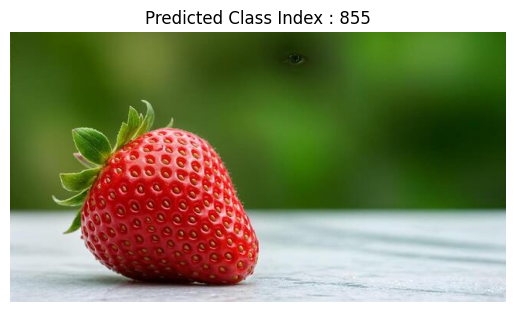

In [9]:
from PIL import Image
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

# Image preprocessing
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

# Load image
img = Image.open("/content/drive/MyDrive/Colab Notebooks/Dataset/ONNX-data/Straberry.jpg")  # put your image path
img_t = transform(img).unsqueeze(0).numpy().astype(np.float32)

# Run ONNX model
output = session.run(None, {input_name: img_t})

# Get predicted class
pred = np.argmax(output[0])

# Show image
plt.imshow(img)
plt.title(f"Predicted Class Index : {pred}")
plt.axis('off')
plt.show()